# BERTopic Topic Labeling and Prevalence Overview

- Summarize how BERTopic themes are labeled and how common each topic is in the WildChat corpus.
- BERTopic produces 76 raw topic clusters; each cluster is assigned a human-readable label and grouped into a broader super-topic category. Clusters sharing the same label are **merged** (summing their weighted prevalence) to avoid double-counting — reducing 76 raw topics to 71 distinct logical topics.
- Compare prevalence at two levels: merged fine-grained topics and 10 broader super-topics.
- Establish a descriptive baseline before moving to demographic relationship analyses.


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_colwidth', 120)
plt.rcParams['axes.grid'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Robust project-root discovery: works even if notebook is nested (e.g., src/analyisis)
start = Path.cwd().resolve()
ROOT = None
for cand in [start, *start.parents]:
    if (cand / 'src').exists() and (cand / 'results').exists():
        ROOT = cand
        break
if ROOT is None:
    raise RuntimeError('Could not locate project root containing both src/ and results/.')

SRC_DIR = ROOT / 'src'
QUAL_DIR = ROOT / 'results' / 'qualitative'
SUM_WHOLE_DIR = ROOT / 'results' / 'summary_whole'
TOPIC_DIR = SRC_DIR / 'topic_modeling' / 'results'

SUMMARY_DIR = ROOT / 'results' / 'summary'

print('ROOT:', ROOT)
print('QUAL_DIR exists:', QUAL_DIR.exists())
print('SUMMARY_DIR:', SUMMARY_DIR)
print('TOPIC_DIR exists:', TOPIC_DIR.exists())


ROOT: /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis
QUAL_DIR exists: True
SUMMARY_DIR: /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary
TOPIC_DIR exists: True


## 1. BERTopic as Main Topic Model

### 1.1 Introduction
We first summarize the BERTopic output structure, including topic labels, super-topic labels, and hierarchy composition. This section establishes the descriptive baseline before linking topics to demographics.

### 1.2 Metrics and Methods
- **Topic labeling**: labels assigned to BERTopic topic clusters (from `topic_level_super_topics.csv`).
- **Label merging**: BERTopic clusters sharing an identical `topic_label` are merged into one logical topic (see §1.4). This reduces 76 raw clusters to 71 distinct merged topics.
- **Weighted prevalence (merged topic)**:

$$
WP_k = \frac{\sum_{s} p_{s,k} \cdot n_s}{\sum_{s} n_s}
$$

where $p_{s,k}$ is the within-state proportion of conversations assigned to topic $k$ in state $s$, and $n_s$ is the total prompt count in state $s$. For merged topics, $p_{s,k}$ is the sum of proportions across all constituent BERTopic clusters.
- **Super-topic prevalence**: weighted sum of all merged-topic prevalences within the same super-topic category.


In [7]:
# Load original topic/super-topic prevalence tables
orig_topic_prev = pd.read_csv(QUAL_DIR / 'd_topic_weighted_prevalence_with_super_topics.csv')
orig_super_prev = pd.read_csv(QUAL_DIR / 'd_super_topic_weighted_prevalence.csv')

OUT_TAB_DIR = SUMMARY_DIR / 'labeled_topics' / 'tables'
OUT_TAB_DIR.mkdir(parents=True, exist_ok=True)

# Show original weighted prevalence before any merging (topic-id level)
orig_show = orig_topic_prev.copy()
orig_show['topic_display'] = (
    orig_show['topic_label'].fillna(orig_show['topic']) + ' [' + orig_show['topic'] + ']'
)
print('Top-10 original topics by weighted prevalence (topic-id level, before merging)')
display(orig_show[['topic', 'topic_display', 'super_topic', 'weighted_prevalence']].head(10))

print('\nAll super-topics by weighted prevalence (original, before merging)')
display(orig_super_prev[['super_topic', 'weighted_prevalence']].sort_values('weighted_prevalence', ascending=False).reset_index(drop=True))


Top-10 original topics by weighted prevalence (topic-id level, before merging)


,topic,topic_display,super_topic,weighted_prevalence
0,topic_2,Translation & Word Meanings [topic_2],Information/Trivia & Explanatory QA,0.067081
1,topic_0,Sports Script Writing [topic_0],Creative Writing & Roleplay,0.064036
2,topic_3,Political History Questions [topic_3],"Politics, Religion, and Society",0.051382
3,topic_1,DDLC Fan Fiction [topic_1],Creative Writing & Roleplay,0.050587
4,topic_4,AI Art Prompting [topic_4],"Media, Art, and Entertainment",0.044703
5,topic_6,Math Problem Solving [topic_6],Education & Homework,0.036077
6,topic_8,Career Resume Help [topic_8],Career & Professional Writing,0.031223
7,topic_5,Monster-Girl Roleplay [topic_5],Creative Writing & Roleplay,0.028529
8,topic_7,Fetish Comedy Stories [topic_7],Creative Writing & Roleplay,0.024532
9,topic_10,Adult Fantasy Fiction [topic_10],Creative Writing & Roleplay,0.024516



All super-topics by weighted prevalence (original, before merging)


,super_topic,weighted_prevalence
0,Creative Writing & Roleplay,0.263037
1,"Media, Art, and Entertainment",0.137196
2,Information/Trivia & Explanatory QA,0.110881
3,Education & Homework,0.103268
4,Career & Professional Writing,0.098380
5,Coding & Technical Help,0.082419
6,"Politics, Religion, and Society",0.072513
7,"Finance, Law, and Practical Life",0.060245
8,Personal Advice & Communication,0.050225
9,"Health, Biology, and Medicine",0.021835


### 1.3 Cross-State Topic Heterogeneity

Before linking topics to demographics, we verify that topic usage **varies systematically across U.S. states** rather than randomly. 
We test each of the 76 raw BERTopics using a **binomial null model**:

- **Observed dispersion**: the weighted variance of a topic's proportion across states, with each state weighted by its document count.
- **Null distribution**: 5 000 synthetic draws in which each state's document pool is independently sampled from a Binomial $(n_s,\, \bar{p})$ 
distribution, where $\bar{p}$ is the globally weighted mean topic proportion. This models the scenario in which every user, regardless of state, has 
the same topic probability—i.e., no geographic signal.
- **Significance**: permutation $p$-value with Benjamini–Hochberg FDR correction ($q < 0.05$).

All 76 BERTopics pass the test, confirming that cross-state variation is real and not sampling noise.

States: 36, Topics: 76, Total docs: 68,668
Significant (FDR q < 0.05): 76/76


,topic_label,super_topic,weighted_dispersion,perm_p_value,fdr_q_value,significant
0,Sports Script Writing,Creative Writing & Roleplay,0.035699,0.0002,0.0002,True
1,DDLC Fan Fiction,Creative Writing & Roleplay,0.021564,0.0002,0.0002,True
2,Fetish Comedy Stories,Creative Writing & Roleplay,0.015999,0.0002,0.0002,True
3,Translation & Word Meanings,Information/Trivia & Explanatory QA,0.014886,0.0002,0.0002,True
4,Scam-Baiting Emails,"Finance, Law, and Practical Life",0.009700,0.0002,0.0002,True
5,Fan Crossover Shipping,Creative Writing & Roleplay,0.007144,0.0002,0.0002,True
6,Monster-Girl Roleplay,Creative Writing & Roleplay,0.005744,0.0002,0.0002,True
7,Political History Questions,"Politics, Religion, and Society",0.005036,0.0002,0.0002,True
8,AI Art Prompting,"Media, Art, and Entertainment",0.004113,0.0002,0.0002,True
9,Versus Battle Scenarios,"Media, Art, and Entertainment",0.004107,0.0002,0.0002,True


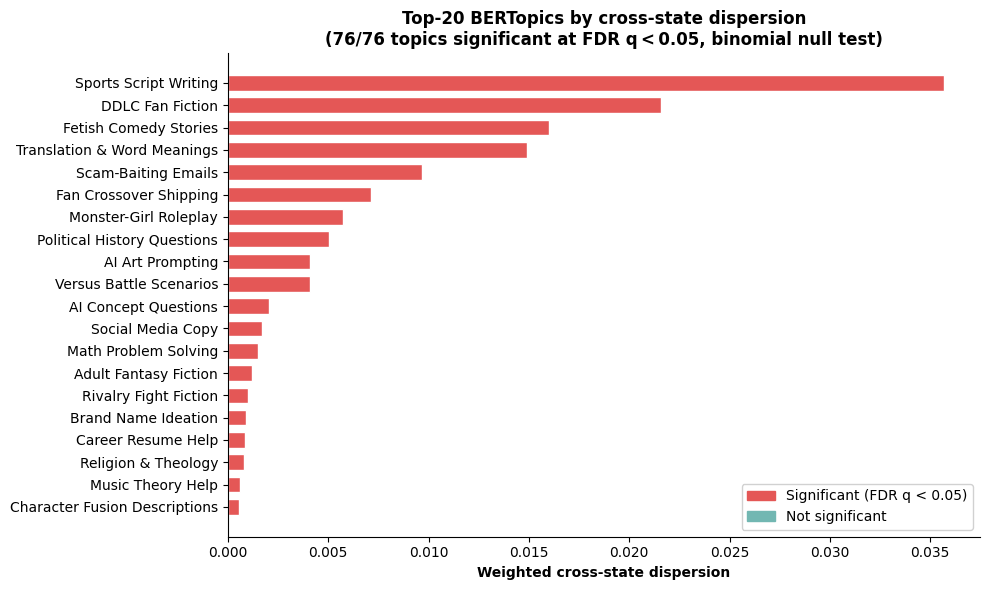

In [8]:
import matplotlib.patches as mpatches
from scipy.stats import false_discovery_control

# ── 1. Load state-topic proportions (wide format: states × topic_0…topic_75) ──
wide = pd.read_parquet(ROOT / 'data/state_topic_proportions.parquet').copy()
wide['state'] = wide['state'].astype(str).str.strip()

# ── 2. Per-state document counts (from the raw corpus) ────────────────────────
wc = pd.read_parquet(ROOT / 'data/wildchat_bertopic.parquet')
wc['state'] = wc['state'].astype(str).str.strip()
state_doc_counts = (
    wc[wc['state'].str.len() > 0]['state']
    .value_counts()
    .rename_axis('state')
    .reset_index(name='state_docs_n')
)
data = wide.merge(state_doc_counts, on='state', how='inner')
weights = data['state_docs_n'].to_numpy(dtype=float)
topic_cols = [c for c in data.columns if c.startswith('topic_')]
n_states, n_topics = len(data), len(topic_cols)
print(f'States: {n_states}, Topics: {n_topics}, Total docs: {int(weights.sum()):,}')

# ── 3. Weighted dispersion (weighted variance across states) ──────────────────
def w_disp(vals, wts):
    wm = np.average(vals, weights=wts)
    return float(np.sum(wts * (vals - wm) ** 2) / np.sum(wts))

# ── 4. Binomial null-model test (5 000 iterations, vectorised per topic) ──────
N_PERM = 5_000
rng    = np.random.default_rng(42)
rows   = []
for topic in topic_cols:
    vals     = data[topic].to_numpy()
    obs      = w_disp(vals, weights)
    global_p = float(np.average(vals, weights=weights))
    # Vectorised: shape (N_PERM, n_states)
    n_int      = weights.astype(int)
    null_props = rng.binomial(n_int, global_p, size=(N_PERM, n_states)) / n_int
    wm_null    = (null_props * weights).sum(1) / weights.sum()
    null_disp  = ((null_props - wm_null[:, None]) ** 2 * weights).sum(1) / weights.sum()
    p_val      = float(((null_disp >= obs).sum() + 1) / (N_PERM + 1))
    rows.append({'topic': topic, 'weighted_dispersion': obs, 'perm_p_value': p_val})

het = pd.DataFrame(rows)
het['fdr_q_value'] = false_discovery_control(het['perm_p_value'], method='bh')
het['significant'] = het['fdr_q_value'] < 0.05

# ── 5. Add human-readable topic labels ───────────────────────────────────────
tl  = pd.read_csv(TOPIC_DIR / 'topic_level_super_topics.csv')[['topic_id', 'topic_label', 'super_topic']]
tl['topic'] = 'topic_' + tl['topic_id'].astype(str)
het = het.merge(tl[['topic', 'topic_label', 'super_topic']], on='topic', how='left')
het['topic_label'] = het['topic_label'].fillna(het['topic'])
het = het.sort_values('weighted_dispersion', ascending=False).reset_index(drop=True)

n_sig = het['significant'].sum()
print(f'Significant (FDR q < 0.05): {n_sig}/{n_topics}')
display(het.head(10)[['topic_label', 'super_topic', 'weighted_dispersion', 'perm_p_value', 'fdr_q_value', 'significant']])

# Save
OUT_TAB_DIR = SUMMARY_DIR / 'labeled_topics' / 'tables'
OUT_TAB_DIR.mkdir(parents=True, exist_ok=True)
het.to_csv(OUT_TAB_DIR / 'topic_state_heterogeneity.csv', index=False)

# ── 6. Figure: top-20 topics by weighted dispersion ──────────────────────────
top20  = het.head(20).reset_index(drop=True)
colors = ['#E45756' if s else '#72B7B2' for s in top20['significant']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20['topic_label'][::-1], top20['weighted_dispersion'][::-1],
        color=colors[::-1], edgecolor='white', height=0.7)
ax.set_xlabel('Weighted cross-state dispersion', fontweight='bold')
ax.set_title(
    f'Top-20 BERTopics by cross-state dispersion\n'
    f'({n_sig}/{n_topics} topics significant at FDR q\u202f<\u202f0.05, binomial null test)',
    fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#E45756', label='Significant (FDR q < 0.05)'),
    mpatches.Patch(color='#72B7B2', label='Not significant'),
], frameon=True, framealpha=0.9)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
OUT_FIG_DIR = SUMMARY_DIR / 'labeled_topics' / 'figures'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
fig.savefig(OUT_FIG_DIR / 'fig_cross_state_topic_dispersion.png', dpi=220, bbox_inches='tight')
plt.show()


### 1.4 Label Merging

BERTopic produces 76 fine-grained topic clusters, but manual labeling revealed that several clusters share identical human-readable labels. 
For example, **"AI Art Prompting"** spans 5 separate BERTopic topic IDs (`topic_4`, `topic_25`, `topic_51`, `topic_60`, `topic_72`) — semantically equivalent clusters that BERTopic split due to minor distributional differences in the corpus.

To avoid double-counting in downstream prevalence and demographic analyses, topics that share the same label are **merged** into a single logical topic. The merge procedure is:

1. **Group** all BERTopic topic IDs that share the same `topic_label`.
2. **Sum** their `weighted_prevalence` values → the merged topic's combined prevalence.
3. **Representative super-topic**: assign the super-topic with the largest combined prevalence contribution within that label group.
4. **Constituent tracking**: record all original topic IDs in a `constituent_topics` field (`|`-separated) for full transparency.
5. **Assign a deterministic `merged_topic_id`** sorted by descending merged prevalence, breaking ties alphabetically.


In [9]:
# Step 1 & 2: group by label, sum prevalence; assign deterministic merged_topic_id
work = orig_topic_prev.copy()
work['topic_label'] = work['topic_label'].fillna(work['topic'])

merged_tmp = (
    work.groupby('topic_label', as_index=False)['weighted_prevalence']
    .sum()
    .sort_values(['weighted_prevalence', 'topic_label'], ascending=[False, True])
    .reset_index(drop=True)
)
merged_tmp['merged_topic_id'] = ['merged_topic_' + str(i) for i in range(len(merged_tmp))]

# Step 3: representative super-topic = super-topic with largest prevalence within the label group
super_choice = (
    work.groupby(['topic_label', 'super_topic'], as_index=False)['weighted_prevalence']
    .sum()
    .sort_values(['topic_label', 'weighted_prevalence'], ascending=[True, False])
    .drop_duplicates(subset=['topic_label'])
    [['topic_label', 'super_topic']]
)

# Step 4: constituent topic IDs for transparency
constituents = (
    work.groupby('topic_label', as_index=False)['topic']
    .agg(lambda x: '|'.join(sorted(set(x))))
    .rename(columns={'topic': 'constituent_topics'})
)

# Assemble final merged table
merged_topic_prev = (
    merged_tmp
    .merge(super_choice,  on='topic_label', how='left')
    .merge(constituents,  on='topic_label', how='left')
    .rename(columns={'topic_label': 'topic_label_merged'})
)

# Expose as topic_prev for downstream compatibility
topic_prev = merged_topic_prev.rename(columns={'topic_label_merged': 'topic_label'}).copy()

# Recalculate super-topic prevalence from merged topics
super_prev = (
    topic_prev.groupby('super_topic', as_index=False)['weighted_prevalence']
    .sum()
    .sort_values('weighted_prevalence', ascending=False)
)

# Save merged tables
orig_show.to_csv(OUT_TAB_DIR / 'original_topic_weighted_prevalence_with_display.csv', index=False)
merged_topic_prev.to_csv(OUT_TAB_DIR / 'merged_topic_weighted_prevalence.csv', index=False)
super_prev.to_csv(OUT_TAB_DIR / 'merged_super_topic_weighted_prevalence.csv', index=False)

print(f'Original topics: {len(orig_topic_prev)}  →  Merged topics: {len(topic_prev)}')
print(f'  Duplicates collapsed: {len(orig_topic_prev) - len(topic_prev)}')
print()
print('Top-10 merged topics by weighted prevalence')
display(topic_prev[['merged_topic_id', 'topic_label', 'super_topic', 'weighted_prevalence', 'constituent_topics']].head(10))

print('All super-topics by weighted prevalence (merged topics)')
display(super_prev[['super_topic', 'weighted_prevalence']].reset_index(drop=True))

print('\nSaved merged tables to', OUT_TAB_DIR)


Original topics: 76  →  Merged topics: 71
  Duplicates collapsed: 5

Top-10 merged topics by weighted prevalence


,merged_topic_id,topic_label,super_topic,weighted_prevalence,constituent_topics
0,merged_topic_0,AI Art Prompting,"Media, Art, and Entertainment",0.070014,topic_25|topic_4|topic_51|topic_60|topic_72
1,merged_topic_1,Translation & Word Meanings,Information/Trivia & Explanatory QA,0.067081,topic_2
2,merged_topic_2,Sports Script Writing,Creative Writing & Roleplay,0.064036,topic_0
3,merged_topic_3,Political History Questions,"Politics, Religion, and Society",0.051382,topic_3
4,merged_topic_4,DDLC Fan Fiction,Creative Writing & Roleplay,0.050587,topic_1
5,merged_topic_5,Math Problem Solving,Education & Homework,0.036077,topic_6
6,merged_topic_6,Career Resume Help,Career & Professional Writing,0.031223,topic_8
7,merged_topic_7,Monster-Girl Roleplay,Creative Writing & Roleplay,0.028529,topic_5
8,merged_topic_8,Fetish Comedy Stories,Creative Writing & Roleplay,0.024532,topic_7
9,merged_topic_9,Adult Fantasy Fiction,Creative Writing & Roleplay,0.024516,topic_10


All super-topics by weighted prevalence (merged topics)


,super_topic,weighted_prevalence
0,Creative Writing & Roleplay,0.263037
1,"Media, Art, and Entertainment",0.137196
2,Information/Trivia & Explanatory QA,0.110881
3,Education & Homework,0.103268
4,Career & Professional Writing,0.098380
5,Coding & Technical Help,0.082419
6,"Politics, Religion, and Society",0.072513
7,"Finance, Law, and Practical Life",0.060245
8,Personal Advice & Communication,0.050225
9,"Health, Biology, and Medicine",0.021835



Saved merged tables to /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary/labeled_topics/tables


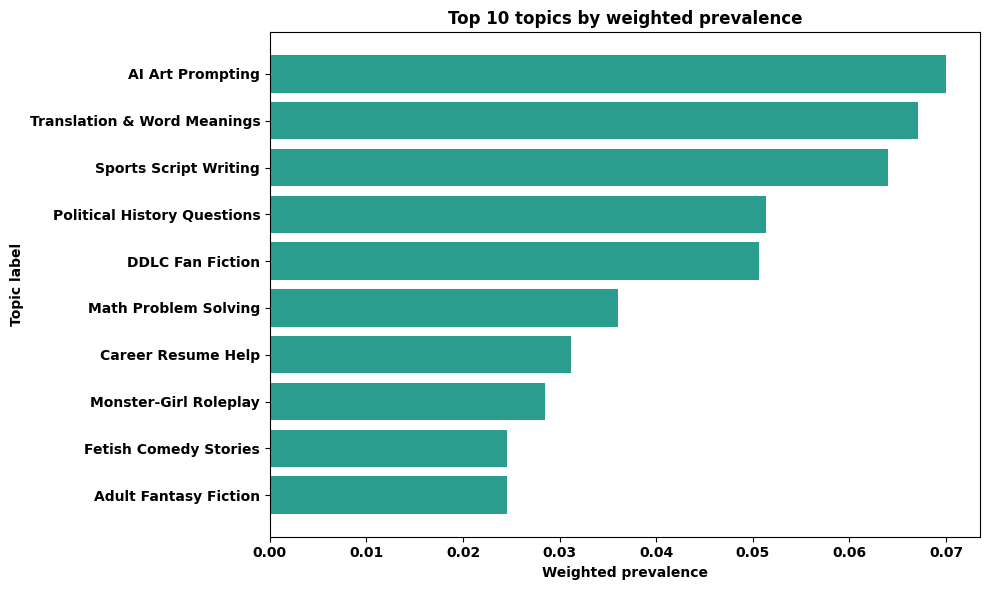

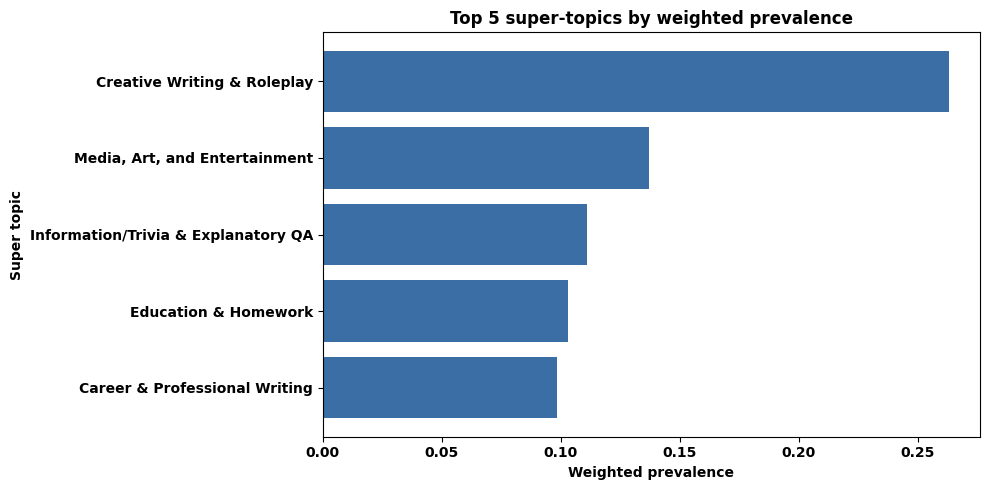

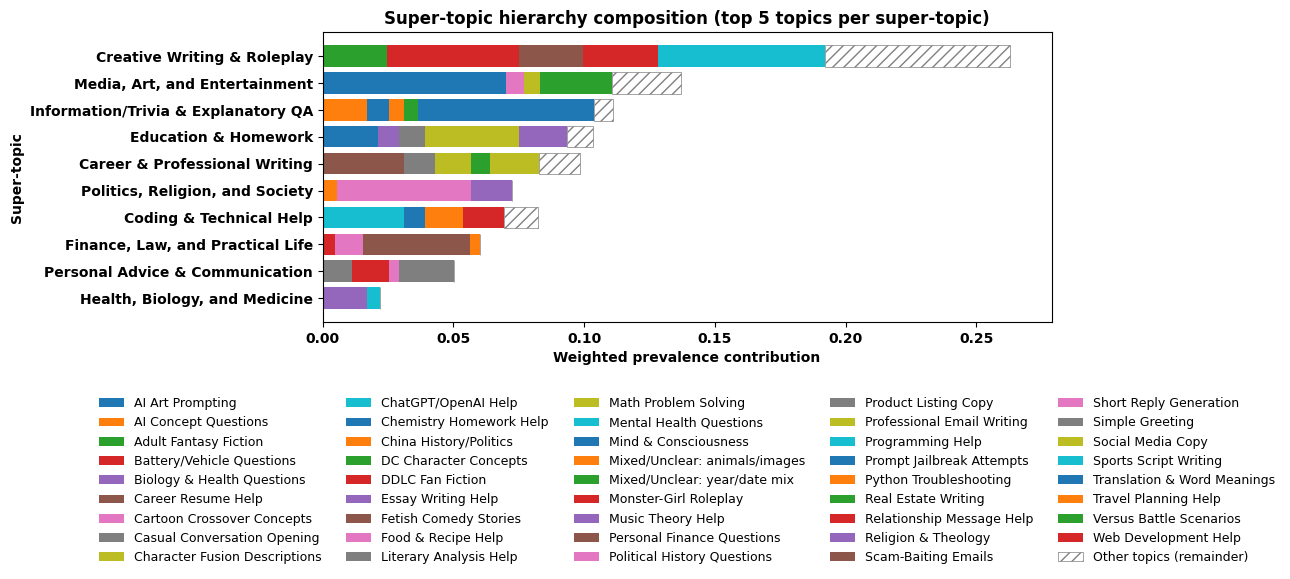

Saved figures to /Users/faylong/Library/Mobile Documents/com~apple~CloudDocs/School Works/EN.601.6672 NLP for computational social science/course-project/wildchat-demographics-analysis/results/summary/labeled_topics/figures


In [10]:
# Draw figures here and save to results/summary
OUT_FIG_DIR = SUMMARY_DIR / 'labeled_topics' / 'figures'
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# 1) Top-10 topic weighted prevalence
plot_df = topic_prev.sort_values('weighted_prevalence', ascending=False).head(10).copy()
plot_df = plot_df.sort_values('weighted_prevalence', ascending=True)
labels = plot_df['topic_label'].fillna(plot_df['merged_topic_id'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, plot_df['weighted_prevalence'], color='#2A9D8F')
ax.set_xlabel('Weighted prevalence', fontweight='bold')
ax.set_ylabel('Topic label', fontweight='bold')
ax.set_title('Top 10 topics by weighted prevalence', fontweight='bold')
for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontweight('bold')
plt.tight_layout()
fig.savefig(OUT_FIG_DIR / 'fig_top10_topic_weighted_prevalence.png', dpi=220)
plt.show()

# 2) Top-5 super-topic weighted prevalence
sp = super_prev.head(5).sort_values('weighted_prevalence', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sp['super_topic'], sp['weighted_prevalence'], color='#3A6EA5')
ax.set_xlabel('Weighted prevalence', fontweight='bold')
ax.set_ylabel('Super topic', fontweight='bold')
ax.set_title('Top 5 super-topics by weighted prevalence', fontweight='bold')
for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontweight('bold')
plt.tight_layout()
fig.savefig(OUT_FIG_DIR / 'fig_top5_super_topic_weighted_prevalence.png', dpi=220)
plt.show()

# 3) Super-topic hierarchy composition (top-5 topics within each super-topic)
hier = topic_prev[['super_topic', 'topic_label', 'weighted_prevalence']].copy()
hier['topic_label'] = hier['topic_label'].fillna('Unlabeled topic')
rows = []
for s, g in hier.groupby('super_topic'):
    rows.append(g.sort_values('weighted_prevalence', ascending=False).head(5))
stack_df = pd.concat(rows, ignore_index=True)
pivot = stack_df.pivot_table(index='super_topic', columns='topic_label', values='weighted_prevalence', fill_value=0)

# Keep bars sorted by total prevalence from top to bottom
totals = pivot.sum(axis=1).sort_values(ascending=False)
pivot = pivot.loc[totals.index]

fig, ax = plt.subplots(figsize=(12, 7))
left = np.zeros(len(pivot))
for col in pivot.columns:
    vals = pivot[col].to_numpy()
    ax.barh(pivot.index, vals, left=left, label=col)
    left += vals

# Add hatched segment for the remaining prevalence not captured by top-5
full_totals = hier.groupby('super_topic')['weighted_prevalence'].sum()
top5_totals = pivot.sum(axis=1).reindex(pivot.index)
remainder = full_totals.reindex(pivot.index) - top5_totals
ax.barh(pivot.index, remainder.values, left=top5_totals.values,
        color='white', edgecolor='gray', hatch='///', linewidth=0.5,
        label='Other topics (remainder)')

ax.invert_yaxis()
ax.set_xlim(0, full_totals.max() * 1.06)
ax.set_xlabel('Weighted prevalence contribution', fontweight='bold')
ax.set_ylabel('Super-topic', fontweight='bold')
ax.set_title('Super-topic hierarchy composition (top 5 topics per super-topic)', fontweight='bold')
for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontweight('bold')

# Move legend below and arrange entries horizontally to avoid empty side space
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=5,
    frameon=False,
    fontsize=9,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(OUT_FIG_DIR / 'fig_super_topic_hierarchy_composition.png', dpi=220, bbox_inches='tight')
plt.show()

print('Saved figures to', OUT_FIG_DIR)


### 1.5 Conclusion

At the super-topic level, **Creative Writing & Roleplay** dominates with 26.3% of weighted prevalence — nearly twice the next-largest category (**Media, Art, and Entertainment**, 13.7%). 
**Information/Trivia & Explanatory QA** (11.1%) and **Education & Homework** (10.3%) rank third and fourth, followed by **Career & Professional Writing** (9.8%) and **Coding & Technical Help** (8.2%). 
The remaining four super-topics together account for about 20%.

At the merged-topic level, the single highest-prevalence topic is **AI Art Prompting** (7.0%) — a merged cluster drawn from five raw BERTopic clusters — followed by **Translation & Word Meanings** (6.7%) and **Sports Script Writing** (6.4%). 
The top-10 topics span five different super-topic categories, confirming the breadth of user intent in the WildChat corpus.

The heterogeneity analysis confirms that all 76 raw BERTopics show **statistically significant cross-state variation** (binomial null test, FDR $q < 0.05$), 
establishing that topic distributions are not uniform across U.S. states. 
This non-random geographic signal motivates the demographic correlation analysis.
